In [1]:
import brian2

brian2.test()

Running tests in c:\Users\codec\Downloads\BRAINDOS\.venv\Lib\site-packages\brian2 for targets numpy, cython (excluding long tests)
Running Brian version 2.10.1 from 'c:\Users\codec\Downloads\BRAINDOS\.venv\Lib\site-packages\brian2'
Testing codegen-independent code
Resetting to default preferences

Running doctests
.........................................                                [100%]
============================== warnings summary ===============================
.venv\Lib\site-packages\_pytest\config\__init__.py:1434
  c:\Users\codec\Downloads\BRAINDOS\.venv\Lib\site-packages\_pytest\config\__init__.py:1434: PytestConfigWarning: Unknown config option: timeout
  
    self._warn_or_fail_if_strict(f"Unknown config option: {key}\n")

input/timedarray.py: 1 warning
monitors/spikemonitor.py: 8 warnings
monitors/statemonitor.py: 3 warnings
parsing/statements.py: 2 warnings
synapses/synapses.py: 22 warnings
  c:\Users\codec\Downloads\BRAINDOS\.venv\Lib\site-packages\brian2\parsing\sta

True

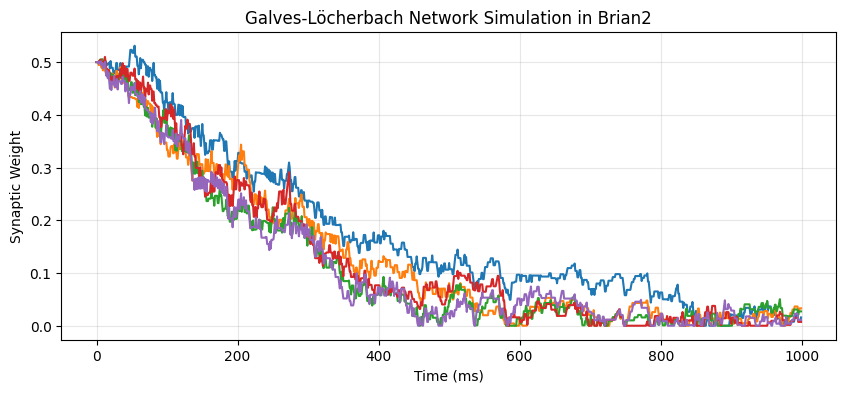

In [24]:
import brian2
from brian2 import *

brian2.start_scope()

N = 100
duration = 1000 * ms
dt = 1 * ms
defaultclock.dt = dt

k=0.5
x0=3.0
spontaneous_rate = 0.002

tau_stdp = 20 * ms
delta_pre = 0.005
delta_post = -0.006
w_max = 3.0

decay_factor = exp(-1 / 20)

eqs= '''
    di_input/dt = - i_input / (10*ms) : 1
    rand_roll = rand() : 1 (constant over dt)
    dapre/dt = -apre / tau_stdp : 1
    dapost/dt = -apost / tau_stdp : 1
'''

gl_threshold = 'rand_roll < (spontaneous_rate + (1.0 - spontaneous_rate) / (1.0 + exp(-k * (i_input -x0))))'

gl_reset = '''
i_input = 0
apre += 0.5
apost += 0.5
'''

neurons = NeuronGroup(N, eqs, threshold=gl_threshold, reset=gl_reset, method='euler')

namespace = {
    'delta_pre': delta_pre,
    'delta_post': delta_post,
    'w_max': w_max,
    'decay_factor': decay_factor
}

stdp_eqs = '''
w : 1
'''

on_pre ='''
i_input_post += w
w = clip(w + delta_post * apost_post, 0, w_max)
'''

on_post = '''
w = clip(w + delta_pre * apre_pre, 0, w_max)
'''


synapses = Synapses(neurons, neurons, model=stdp_eqs, on_pre=on_pre, on_post=on_post, namespace=namespace)
synapses.connect(condition = 'i != j', p=0.1)

synapses.w = 0.5 #np.random.uniform(-1, 3, size=len(synapses))

weight_monitor = StateMonitor(synapses, 'w', record=[0,1,2,3,4])

spike_monitor = SpikeMonitor(neurons)

#TESTING COMPONENTS

test_spike_monitor = SpikeMonitor(neurons)

cue_neurons = np.arange(16)
cue_times = np.ones(16) * 1010 * ms
input_generator = SpikeGeneratorGroup(16, cue_neurons, cue_times)

test_synapses = Synapses(input_generator, neurons, on_pre='i_input_post += 5.0')
test_synapses.connect(i=np.arange(16), j=np.arange(16))

test_duration = 100 * ms

#TRAINING
run(duration)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.plot(weight_monitor.t/ms, weight_monitor.w[i], label=f'Synapse {i}')
plt.xlabel('Time (ms)')
plt.ylabel('Synaptic Weight')
plt.title('Galves-Löcherbach Network Simulation in Brian2')
plt.grid(True, alpha=0.3)
plt.show()

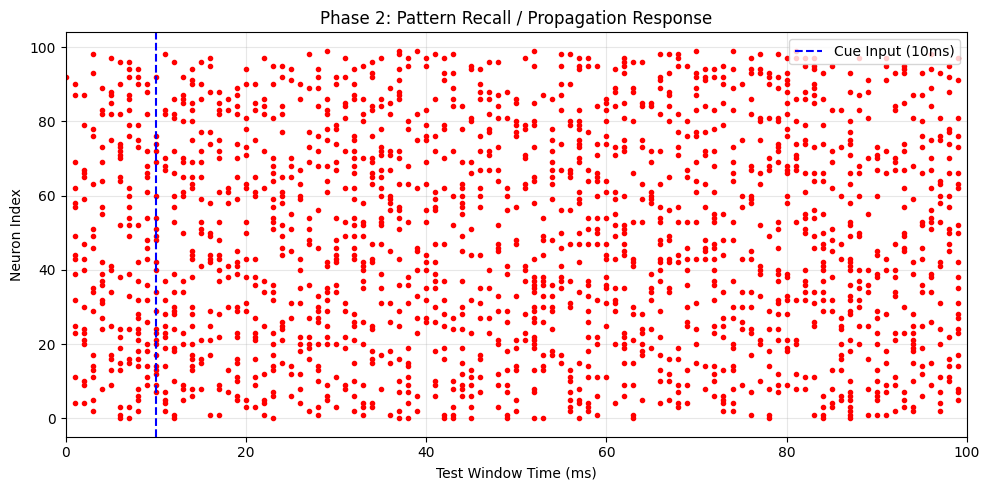

In [33]:
synapses.namespace['delta_pre'] = 0.0
synapses.namespace['delta_post'] = 0.0

synapses.active = False
weight_monitor.active = False

test_synapses.active = True
input_generator.active = True

clean_test_monitor = SpikeMonitor(neurons)
#test_network = Network(neurons, input_generator, test_synapses, test_spike_monitor)

run(test_duration)

plt.figure(figsize=(10, 5))
plt.plot((clean_test_monitor.t - defaultclock.t + test_duration) / ms, clean_test_monitor.i, '.r', ms=6)
plt.axvline(x=10, color='b', linestyle='--', label='Cue Input (10ms)')
plt.xlabel('Test Window Time (ms)')
plt.ylabel('Neuron Index')
plt.title('Phase 2: Pattern Recall / Propagation Response')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
import brian2
from brian2 import *

brian2.start_scope()

N = 100
duration = 1000 * ms
dt = 1 * ms
defaultclock.dt = dt

k=0.5
x0=3.0
spontaneous_rate = 0.002

tau_stdp = 20 * ms
delta_pre = 0.005
delta_post = -0.006
w_max = 3.0

decay_factor = exp(-1 / 20)

eqs= '''
    di_input/dt = - i_input / (10*ms) : 1
    rand_roll = rand() : 1 (constant over dt)
    dapre/dt = -apre / tau_stdp : 1
    dapost/dt = -apost / tau_stdp : 1
'''

gl_threshold = 'rand_roll < (spontaneous_rate + (1.0 - spontaneous_rate) / (1.0 + exp(-k * (i_input -x0))))'

gl_reset = '''
i_input = 0
apre += 0.5
apost += 0.5
'''

neurons = NeuronGroup(N, eqs, threshold=gl_threshold, reset=gl_reset, method='euler')

namespace = {
    'delta_pre': delta_pre,
    'delta_post': delta_post,
    'w_max': w_max,
    'decay_factor': decay_factor
}

stdp_eqs = '''
w : 1
'''

on_pre ='''
i_input_post += w
w = clip(w + delta_post * apost_post, 0, w_max)
'''

on_post = '''
w = clip(w + delta_pre * apre_pre, 0, w_max)
'''


synapses = Synapses(neurons, neurons, model=stdp_eqs, on_pre=on_pre, on_post=on_post, namespace=namespace)
synapses.connect(condition = 'i != j', p=0.1)

synapses.w = 0.5 #np.random.uniform(-1, 3, size=len(synapses))

In [ ]:

#TRAINING PATTERN
pattern_size = 26
cycles = 25
p_neurons = np.tile(np.arange(pattern_size), cycles)
p_times = np.repeat(np.arange(1, cycles + 1) * 40 * ms, pattern_size)






weight_monitor = StateMonitor(synapses, 'w', record=[0,1,2,3,4])

spike_monitor = SpikeMonitor(neurons)

#TESTING COMPONENTS

test_spike_monitor = SpikeMonitor(neurons)

cue_neurons = np.arange(16)
cue_times = np.ones(16) * 1010 * ms
input_generator = SpikeGeneratorGroup(16, cue_neurons, cue_times)

test_synapses = Synapses(input_generator, neurons, on_pre='i_input_post += 5.0')
test_synapses.connect(i=np.arange(16), j=np.arange(16))

test_duration = 100 * ms

#TRAINING
run(duration)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.plot(weight_monitor.t/ms, weight_monitor.w[i], label=f'Synapse {i}')
plt.xlabel('Time (ms)')
plt.ylabel('Synaptic Weight')
plt.title('Galves-Löcherbach Network Simulation in Brian2')
plt.grid(True, alpha=0.3)
plt.show()